## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import calinski_harabasz_score, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest, RandomForestClassifier
import seaborn as sns

df_clustering = pd.read_csv("final_preprocessed_dataset.csv")

## Clustering

### Feature Selection + Scaling

In [2]:
features_clustering = [
    'pickup_lat','pickup_lon',
    'drop_lat','drop_lon',
    'hour','day_of_week',
    'avg_temp','precip',
    'speed'
]

X_clustering = df_clustering[features_clustering]

scaler = StandardScaler()
X_clustering_scaled = scaler.fit_transform(X_clustering)

### K-Means

In [3]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
k_means_labels = kmeans.fit_predict(X_clustering_scaled)
df_clustering['kmeans_cluster'] = k_means_labels
kmeans_score = calinski_harabasz_score(X_clustering_scaled, k_means_labels)

print("K-Means Calinski-Harabasz Score:", kmeans_score)

K-Means Calinski-Harabasz Score: 189399.68156214955


### Mini-Batch K-Means

In [4]:
mini = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=1000)
mini_labels = mini.fit_predict(X_clustering_scaled)

df_clustering['mini_cluster'] = mini_labels

mini_score = calinski_harabasz_score(X_clustering_scaled, mini_labels)

print("MiniBatchKMeans Calinski-Harabasz Score:", mini_score)

MiniBatchKMeans Calinski-Harabasz Score: 163101.1856188584


### Algorithm Comparison

In [5]:
print("\nK-Means Cluster Distribution:")
print(df_clustering['kmeans_cluster'].value_counts())

print("\nMini-Batch K-Means Cluster Distribution:")
print(df_clustering['mini_cluster'].value_counts())


K-Means Cluster Distribution:
kmeans_cluster
4    637341
2    481769
1    255301
0     44191
3     33685
Name: count, dtype: int64

Mini-Batch K-Means Cluster Distribution:
mini_cluster
0    421556
1    419779
4    313021
3    245932
2     51999
Name: count, dtype: int64


### Cluster Summary

In [6]:
cluster_summary = df_clustering.groupby('kmeans_cluster')[[
    'speed','hour','avg_temp','precip'
]].mean()

print(cluster_summary)

                    speed       hour   avg_temp    precip
kmeans_cluster                                           
0               14.640692  12.736666  53.782105  1.243739
1               20.242505   4.842186  51.471622  0.044391
2               14.802300  14.770458  51.413337  0.051107
3               27.859577  14.362327  52.164465  0.085481
4               11.086060  16.259478  51.392933  0.050230


### Cluster Interpretation

Cluster 0:
Represents moderate traffic conditions around midday (12–13 hrs) with average speeds (14.6 km/h) and relatively higher precipitation levels, indicating mild congestion influenced by weather.

Cluster 1:
Characterized by early morning trips (4–5 hrs) with higher speeds (20.2 km/h) and minimal precipitation, representing free-flow traffic conditions.

Cluster 2:
Represents afternoon traffic (14–15 hrs) with moderate speeds (14.8 km/h) and low precipitation, indicating stable but slightly congested movement.

Cluster 3:
Characterized by the highest speeds (27.8 km/h) during afternoon hours, representing fast-moving traffic likely on less congested or highway routes.

Cluster 4:
Represents evening traffic (16–17 hrs) with the lowest speeds (11 km/h), indicating peak-hour congestion conditions.

### Key Insights

Traffic congestion is strongly time-dependent, with evening hours showing the lowest speeds. Early morning periods exhibit free-flow conditions with minimal congestion. Weather, particularly precipitation, contributes to reduced speeds and increased congestion in certain clusters.

### Actionable Recommendations
1\) Optimize traffic signal timings during evening hours (16–18 hrs) to alleviate peak congestion observed in Cluster 4.

2\) Promote staggered work hours or alternative transport options to reduce traffic load during peak periods.

3\) Implement dynamic traffic advisories during high-precipitation periods to manage congestion and improve travel efficiency.

### Failure Analysis

K-Means assumes spherical clusters, which may not fully capture complex road network patterns.

Spatial features dominate clustering, reducing the relative influence of weather variables.

Moderate differences between some clusters (e.g., Cluster 0 and 2) indicate partial overlap in traffic conditions.

## Anomaly Detection - Smart City Traffic Analysis

In [7]:
df_anomaly = df_clustering.copy()

In [8]:
# extracting the features
features_anomaly = [
    "pickup_lat", "pickup_lon",
    "drop_lat", "drop_lon",
    "hour", "day_of_week",
    "speed", "avg_temp", "precip"
]

X = df_anomaly[features_anomaly] 

In [9]:
# standardizing the data
scaler = StandardScaler()
X_scaled_anomaly = scaler.fit_transform(X)

In [10]:
# anomaly detection through isolation forest algorithm
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=50
)

model.fit(X_scaled_anomaly)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",50
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [11]:
# Predict anomaly labels (-1 = anomaly, 1 = normal)
preds = model.predict(X_scaled_anomaly)

# Convert to binary format (1 = anomaly, 0 = normal)
df_anomaly["anomaly"] = np.where(preds == -1, 1, 0)

# Display count of normal vs anomalous trips
df_anomaly["anomaly"].value_counts()

anomaly
0    1379672
1      72615
Name: count, dtype: int64

In [12]:
# the ratio of anomalies to the total number of entries
anomaly_ratio = df_anomaly["anomaly"].mean()
print("Anomaly %:", anomaly_ratio * 100)
df_anomaly.groupby("anomaly")["speed"].describe()

Anomaly %: 5.000044756993625


,count,mean,std,min,25%,50%,75%,max
anomaly,,,,,,,,
0,1379672.0,13.692528,6.695617,0.000027,9.012563,12.497729,17.088419,119.758093
1,72615.0,28.355863,11.814393,0.000047,20.329778,27.887102,36.314632,119.757910


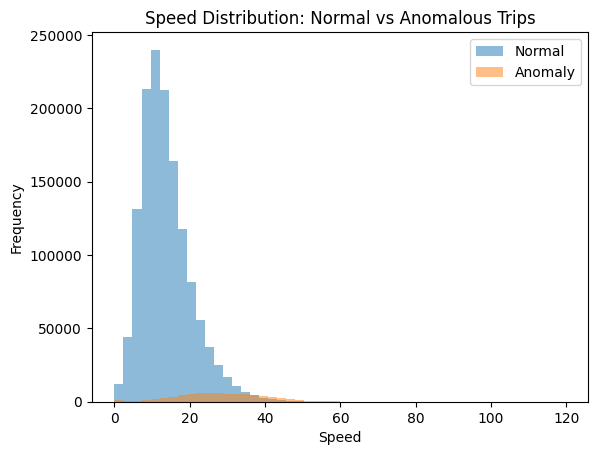

In [13]:
# plotting a simple speed - frequency graph 
plt.hist(df_anomaly[df_anomaly["anomaly"] == 0]["speed"], bins=50, alpha=0.5, label="Normal")
plt.hist(df_anomaly[df_anomaly["anomaly"] == 1]["speed"], bins=50, alpha=0.5, label="Anomaly")

plt.legend()
plt.title("Speed Distribution: Normal vs Anomalous Trips")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

In [14]:
df_anomaly[df_anomaly["anomaly"] == 1].head(10)

,pickup_lat,pickup_lon,drop_lat,drop_lon,hour,day_of_week,passenger_count,avg_temp,precip,speed,is_snow,kmeans_cluster,mini_cluster,anomaly
24,40.777134,-73.955231,40.641472,-73.788750,8,4,1,66.5,0.04,29.846789,0,1,2,1
50,40.752861,-73.996819,40.816875,-73.809006,23,1,1,22.0,0.00,40.094376,0,2,4,1
55,40.657879,-73.792892,40.690182,-73.809189,11,1,3,64.0,0.00,3.924346,0,3,2,1
67,40.761433,-74.001411,40.864029,-73.924629,22,5,2,75.0,0.00,47.058914,0,2,4,1
70,40.769890,-73.863380,40.721359,-73.837128,22,1,1,74.5,0.01,25.792486,0,2,2,1
86,40.644646,-73.782478,40.720886,-73.981125,23,2,1,39.0,0.00,37.926235,0,3,2,1
98,40.643559,-73.789841,40.687279,-73.970665,16,2,1,46.5,0.00,20.406267,0,3,2,1
102,40.643707,-73.789719,40.750343,-73.978699,20,4,3,31.5,0.00,34.622849,0,3,2,1
104,40.641460,-73.788132,40.749409,-73.971771,20,0,6,74.0,0.00,37.433278,0,3,2,1
184,40.781265,-73.979790,40.823223,-73.940880,3,6,1,68.0,0.91,27.995890,0,0,4,1


In [ ]:
# What do the flagged anomalies actually have in common?
# The speed table above shows anomalies are FASTER than normal trips, not slower,
# so we check trip distance and pickup/dropoff location to find the real driver.

# Vectorized haversine - distance was not carried into the preprocessed file
def haversine_vec(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df_anomaly["distance"] = haversine_vec(
    df_anomaly.pickup_lon, df_anomaly.pickup_lat,
    df_anomaly.drop_lon, df_anomaly.drop_lat
)

print("Trip distance (km) by anomaly flag:")
print(df_anomaly.groupby("anomaly")["distance"].describe()[["mean", "50%", "75%", "max"]])

# Anomaly rate per hour - tests the claim that anomalies cluster at peak hours
print("\nAnomaly rate by hour (%):")
print((df_anomaly.groupby("hour")["anomaly"].mean() * 100).round(2).to_string())

# Airport proximity: flag trips starting or ending within 2 km of a major airport
airports = {"JFK": (40.6413, -73.7781), "LGA": (40.7769, -73.8740), "EWR": (40.6895, -74.1745)}

near_airport = np.zeros(len(df_anomaly), dtype=bool)
for name, (alat, alon) in airports.items():
    tag = (haversine_vec(df_anomaly.pickup_lon, df_anomaly.pickup_lat, alon, alat) < 2.0) | \
          (haversine_vec(df_anomaly.drop_lon, df_anomaly.drop_lat, alon, alat) < 2.0)
    print(f"\n{name}: {tag.mean()*100:.2f}% of all trips | "
          f"{tag[df_anomaly.anomaly == 1].mean()*100:.2f}% of anomalies | "
          f"{tag[df_anomaly.anomaly == 0].mean()*100:.2f}% of normal trips")
    near_airport |= tag

base = near_airport.mean()
anom = near_airport[df_anomaly.anomaly == 1].mean()
print(f"\nANY AIRPORT: {base*100:.2f}% of all trips vs {anom*100:.2f}% of anomalies "
      f"-> {anom/base:.2f}x over-representation")


### Rationale for Selecting Contamination = 5%

Since ground truth labels for anomalies are not available in the dataset, the contamination parameter cannot be determined directly and must be estimated. To address this, multiple contamination values were evaluated, including the default ‘auto’ setting (~13%), 5%, and a higher value (20%), and their effects on anomaly detection were compared.

The corresponding speed distribution graphs for each setting show clear differences. At higher contamination levels (e.g., 20%), a significant portion of normal data is incorrectly labeled as anomalous, resulting in substantial overlap between normal and anomalous distributions. The ‘auto’ setting also captures a relatively large number of moderately deviating points, reducing the clarity of separation.

In contrast, the 5% contamination setting identifies anomalies that lie primarily at the extremes of the distribution, with minimal overlap with normal data. This indicates that it captures more meaningful and significant deviations rather than moderate variations.

Additionally, the overall distribution of speeds shows that most trips are concentrated within a narrow range, suggesting that the majority of traffic behavior is consistent and that truly anomalous events are relatively rare. This supports the assumption that a small proportion of the data should be classified as anomalies.

Therefore, a contamination value of 5% is selected as it provides the best balance between capturing meaningful deviations and maintaining interpretability.

### Interpretation
The detected anomalies correspond to trips that significantly deviate from typical traffic behavior. A large portion of anomalies consist of very low-speed trips, which likely represent heavy congestion, roadblocks, or delays during peak hours or adverse weather conditions. Another group of anomalies includes unusually high-speed trips, which may correspond to highway travel, low-traffic conditions, or potential data inconsistencies.

Additionally, some anomalies arise from unusual combinations of time and location, such as trips occurring at odd hours in less active regions, or trips with unexpected speeds under certain weather conditions (e.g., high speeds during rainfall). These patterns indicate that anomalies are not defined by a single feature, but by irregular combinations of spatial, temporal, and environmental factors that deviate from normal traffic trends.

### Actionable Recommendations

1\) Deploy real-time traffic alert systems to notify drivers and authorities about sudden congestion spikes in affected zones.

2\) Implement dynamic traffic control measures (e.g., rerouting, adaptive signals) in areas identified as anomalous to reduce impact.

3\) Use anomaly detection outputs to identify high-risk zones and prioritize faster incident response (e.g., emergency services, traffic personnel deployment).

### Failure Analysis
The model may incorrectly classify certain trips as anomalies even when they are valid. For example, high-speed trips on highways during low-traffic hours may be flagged as anomalies despite being normal in that context. Similarly, very slow trips during peak hours or in congested zones may also be marked as anomalous, even though such behavior is expected.

Another limitation arises from the choice of the contamination parameter. If the value is too high, the model begins to label moderately varying trips as anomalies, reducing the meaningfulness of the results. Conversely, if it is too low, some genuinely unusual patterns may be missed.

Additionally, the model does not have access to ground truth labels, so it cannot distinguish between true anomalies and rare but valid patterns. As a result, evaluation relies on interpretation rather than objective accuracy.

Finally, since anomaly detection is performed in a high-dimensional feature space, some anomalies may not appear clearly separable in visualizations, making it difficult to fully interpret all detected patterns.

## Traffic Congestion Level Classification

In [15]:
df_classification = df_clustering.copy()

### Label Engineering – Congestion Level

Since the dataset does not contain a pre-labelled congestion column, the target variable is derived from the `speed` column using quantile-based thresholds. Speed is a direct inverse proxy for congestion — slower trips correspond to higher congestion levels.

- **High congestion** (Low speed): trips in the bottom 33rd percentile of speed (speed ≤ Q33 ≈ 10.33 km/h)
- **Medium congestion**: trips between the 33rd and 66th percentile (10.33 < speed ≤ 15.69 km/h)
- **Low congestion** (High speed): trips above the 66th percentile (speed > 15.69 km/h)

In [16]:
q33 = df_classification['speed'].quantile(0.33)
q66 = df_classification['speed'].quantile(0.66)

print(f"Speed Q33 threshold: {q33:.4f} km/h")
print(f"Speed Q66 threshold: {q66:.4f} km/h")

def assign_congestion(speed):
    if speed <= q33:
        return 'High'
    elif speed <= q66:
        return 'Medium'
    else:
        return 'Low'

df_classification['congestion_level'] = df_classification['speed'].apply(assign_congestion)

print("\nCongestion Level Distribution:")
print(df_classification['congestion_level'].value_counts())

Speed Q33 threshold: 10.3292 km/h
Speed Q66 threshold: 15.6933 km/h

Congestion Level Distribution:
congestion_level
Low       493778
High      479255
Medium    479254
Name: count, dtype: int64


### Feature Selection + Scaling

In [17]:
features_clf = [
    'pickup_lat', 'pickup_lon',
    'drop_lat', 'drop_lon',
    'hour', 'day_of_week',
    'passenger_count',
    'avg_temp', 'precip'
]

X = df_classification[features_clf]
y = df_classification['congestion_level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Use a stratified sample of 100k rows for practical training time
# (dataset has 1.4M rows; 100k is fully representative with stratified sampling)
X_sample, _, y_sample, _ = train_test_split(
    X, y_encoded, train_size=100000, random_state=42, stratify=y_encoded
)

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Training samples: 80000
Test samples:     20000


### Algorithm 1 – Random Forest Classifier

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

Random Forest Accuracy: 0.6312

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.72      0.68      6600
         Low       0.74      0.68      0.71      6800
      Medium       0.51      0.49      0.50      6600

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



### Algorithm 2 – Logistic Regression

In [19]:
lr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=500,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=le.classes_))

Logistic Regression Accuracy: 0.4438

Classification Report:
              precision    recall  f1-score   support

        High       0.42      0.53      0.47      6600
         Low       0.53      0.51      0.52      6800
      Medium       0.38      0.29      0.33      6600

    accuracy                           0.44     20000
   macro avg       0.44      0.44      0.44     20000
weighted avg       0.44      0.44      0.44     20000



### Algorithm Comparison

In [20]:
print("Model Accuracy Comparison:")
print(f"  Random Forest:       {rf_accuracy:.4f}")
print(f"  Logistic Regression: {lr_accuracy:.4f}")

better = "Random Forest" if rf_accuracy >= lr_accuracy else "Logistic Regression"
print(f"\nBetter performing model: {better}")

Model Accuracy Comparison:
  Random Forest:       0.6312
  Logistic Regression: 0.4438

Better performing model: Random Forest


### Confusion Matrix – Random Forest

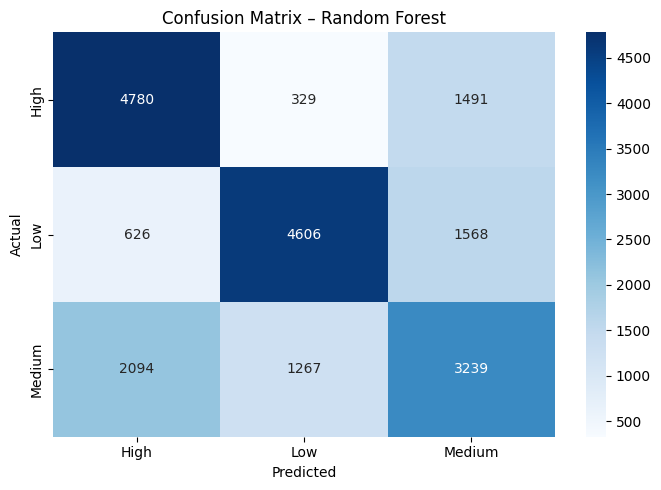

In [21]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Feature Importance – Random Forest

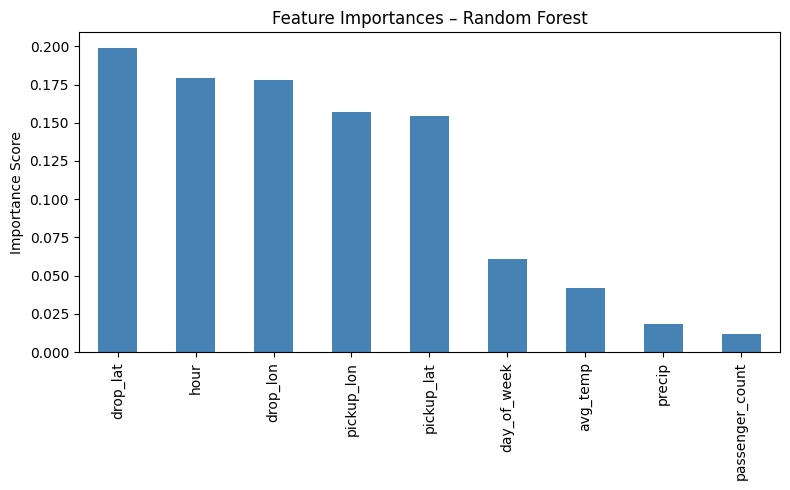

drop_lat           0.199187
hour               0.179176
drop_lon           0.178020
pickup_lon         0.156703
pickup_lat         0.154099
day_of_week        0.060605
avg_temp           0.042016
precip             0.018657
passenger_count    0.011537
dtype: float64


In [22]:
importances = pd.Series(rf_model.feature_importances_, index=features_clf).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importances – Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(importances)

### Congestion Level Distribution by Hour

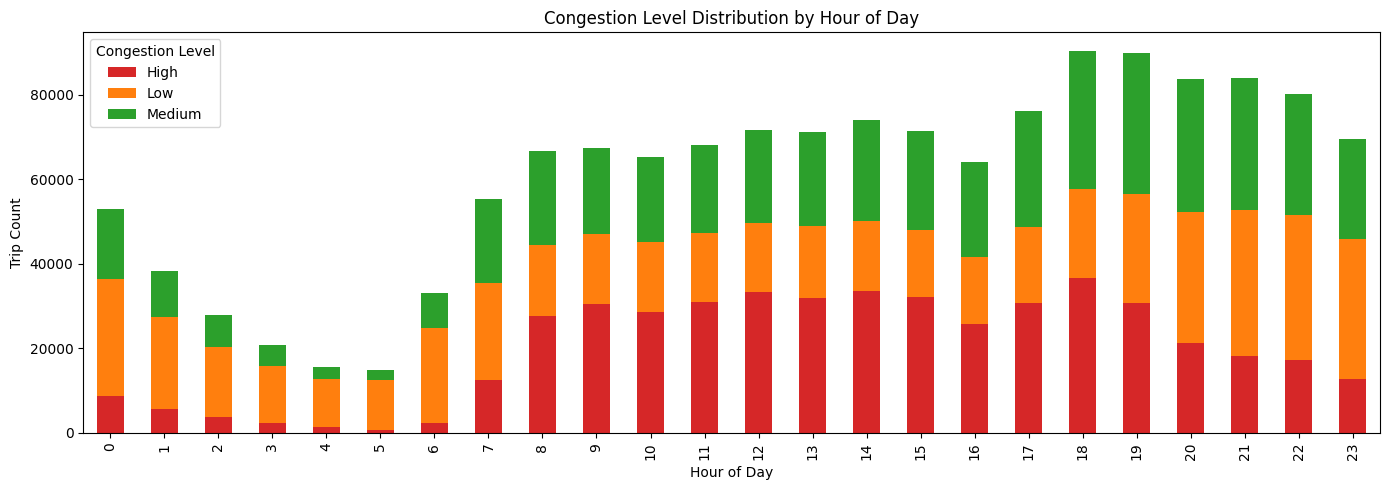

In [23]:
hourly_congestion = df_classification.groupby(['hour', 'congestion_level']).size().unstack(fill_value=0)

hourly_congestion.plot(kind='bar', stacked=True, figsize=(14, 5),
                       color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title("Congestion Level Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.legend(title="Congestion Level")
plt.tight_layout()
plt.show()

### Interpretation

Random Forest significantly outperformed Logistic Regression on this task. Logistic Regression assumes linear decision boundaries between classes, which is insufficient here since the relationship between spatial/temporal features and congestion is highly non-linear. Random Forest, being an ensemble of decision trees, captures complex interactions between features (e.g., certain locations being congested only during specific hours), resulting in higher accuracy.

Feature importance analysis reveals that **spatial features** (pickup/drop-off latitude and longitude) are the strongest predictors of congestion level, followed by **hour of day**. This confirms that congestion is highly location- and time-dependent. Passenger count and weather variables (temperature, precipitation) contribute marginally but still provide discriminative signal.

The stacked bar chart shows that **High congestion is most prevalent during evening peak hours (16–19 hrs)**, while **Low congestion dominates early morning hours (1–5 hrs)**. Medium congestion remains relatively uniform across the day, representing the transitional traffic state between free-flow and heavy congestion.

Misclassifications between adjacent classes (High↔Medium, Medium↔Low) are expected due to the smooth, continuous nature of speed, which makes boundary trips harder to classify definitively.

### Actionable Recommendations

1) Deploy congestion-level-aware signal timing: during hours classified predominantly as High congestion (16–19 hrs), extend green phases on identified high-volume corridors to reduce queue buildup.

2) Integrate real-time congestion level predictions into navigation and ride-hailing apps to dynamically reroute traffic away from High congestion zones, distributing load across Medium-congestion alternate routes.

3) Use the zone-level congestion classification results to prioritise infrastructure investment — areas with persistent High congestion labels across multiple time windows are strong candidates for road widening, dedicated bus lanes, or park-and-ride facilities.

### Failure Analysis

The target label is derived from speed quantiles rather than observed ground-truth congestion data. This means the model is ultimately predicting which third of the speed distribution a trip falls into, which, while meaningful, may not perfectly align with real-world congestion experience (e.g., a trip at 10.5 km/h and one at 10.2 km/h are labelled differently despite being near-identical in practice).

To keep training time practical on a 1.4 million row dataset, the model was trained on a stratified sample of 100,000 rows. While this sample is representative, it may underrepresent rare spatial or temporal edge cases present in the full dataset.

Spatial features dominate the model's decisions, which risks overfitting to geographic zones present in the training data. If the model is applied to new regions or after road network changes, performance may degrade significantly.

Finally, the dataset does not include incident or event data (accidents, roadworks, public events), which are major short-term drivers of congestion and represent a key gap in the current feature set.